In [1]:
import pandas as pd
import numpy as np
import missingno as msno
import seaborn as sns
from scipy import sparse

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import StratifiedKFold, train_test_split
import lightgbm as lgb
from bayes_opt import BayesianOptimization

import xgboost as xgb

%matplotlib inline

In [2]:
train = pd.read_csv("data/train.csv", index_col = "id")
test = pd.read_csv("data/test.csv", index_col = "id")
submission = pd.read_csv("data/sample_submission.csv", index_col = "id")

# 1. Exploratory Data Analysis

In [34]:
train.shape, test.shape

((595212, 58), (892816, 57))

- A lot of features
- The dataset is huge

In [35]:
train.head()

,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
id,,,,,,,,,,,,,,,,,,,,,
7,0,2,2,5,1,0,0,1,0,0,...,9,1,5,8,0,1,1,0,0,1
9,0,1,1,7,0,0,0,0,1,0,...,3,1,1,9,0,1,1,0,1,0
13,0,5,4,9,1,0,0,0,1,0,...,4,2,7,7,0,1,1,0,1,0
16,0,0,1,2,0,0,1,0,0,0,...,2,2,4,9,0,0,0,0,0,0
17,0,0,2,0,1,0,1,0,0,0,...,3,1,1,3,0,0,0,1,1,0


In [24]:
test.head()

,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,ps_ind_10_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
id,,,,,,,,,,,,,,,,,,,,,
0,0,1,8,1,0,0,1,0,0,0,...,1,1,1,12,0,1,1,0,0,1
1,4,2,5,1,0,0,0,0,1,0,...,2,0,3,10,0,0,1,1,0,1
2,5,1,3,0,0,0,0,0,1,0,...,4,0,2,4,0,0,0,0,0,0
3,0,1,6,0,0,1,0,0,0,0,...,5,1,0,5,1,0,1,0,0,0
4,5,1,7,0,0,0,0,0,1,0,...,4,0,0,4,0,1,1,0,0,1


In [25]:
submission.head()

,target
id,
0,0.0364
1,0.0364
2,0.0364
3,0.0364
4,0.0364


In [26]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 595212 entries, 7 to 1488027
Data columns (total 58 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   target          595212 non-null  int64  
 1   ps_ind_01       595212 non-null  int64  
 2   ps_ind_02_cat   595212 non-null  int64  
 3   ps_ind_03       595212 non-null  int64  
 4   ps_ind_04_cat   595212 non-null  int64  
 5   ps_ind_05_cat   595212 non-null  int64  
 6   ps_ind_06_bin   595212 non-null  int64  
 7   ps_ind_07_bin   595212 non-null  int64  
 8   ps_ind_08_bin   595212 non-null  int64  
 9   ps_ind_09_bin   595212 non-null  int64  
 10  ps_ind_10_bin   595212 non-null  int64  
 11  ps_ind_11_bin   595212 non-null  int64  
 12  ps_ind_12_bin   595212 non-null  int64  
 13  ps_ind_13_bin   595212 non-null  int64  
 14  ps_ind_14       595212 non-null  int64  
 15  ps_ind_15       595212 non-null  int64  
 16  ps_ind_16_bin   595212 non-null  int64  
 17  ps_ind_17_bin 

- The first key words after ps, including [in, reg, car, calc] are classficiations.
- After classficiations, there are serial numbers.
- After serial numbers, there are data types including [Non, binary, categorical].

- Classification and serial numbers provide no meaningful information here.
- The data is anonymized, so the meaning of each classification is unknown.
- Additionally, while the data indicates no missing values in any features, a value of -1 has been inputted in places where data is missing, leading to the assumption that there are no missing values.

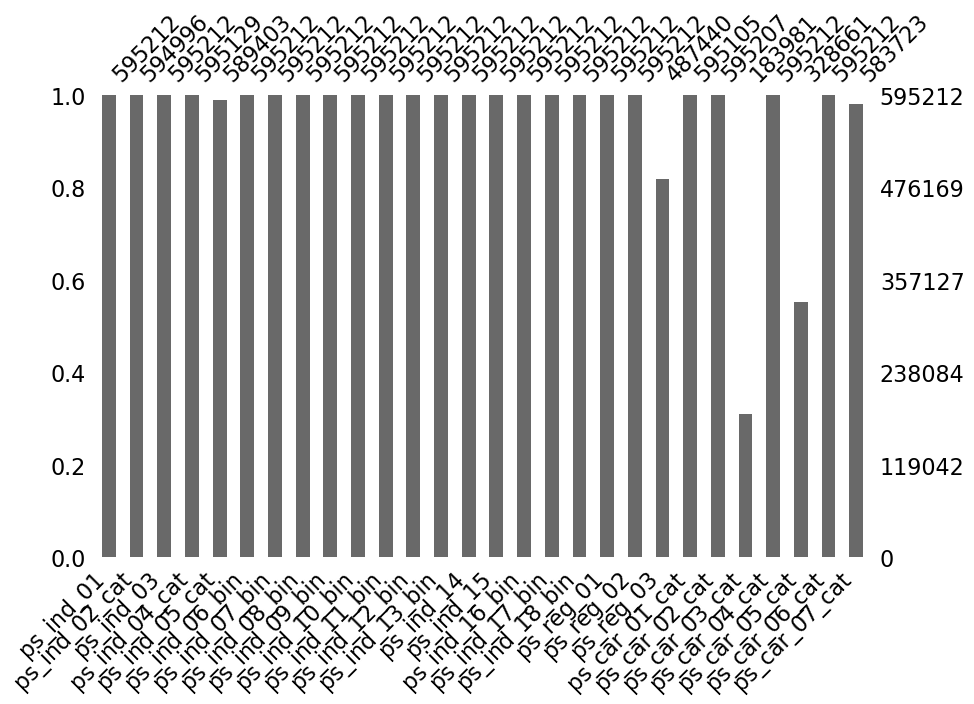

In [27]:
train_copy = train.copy().replace(-1, np.NaN)

msno.bar(df = train_copy.iloc[:, 1:29], figsize = (10, 6));

- To find out the real number of missing values, I changed the -1 to NaN.
- we can observe that ps_reg_03, ps_car_03_cat, ps_car_05_cat are having missing values.

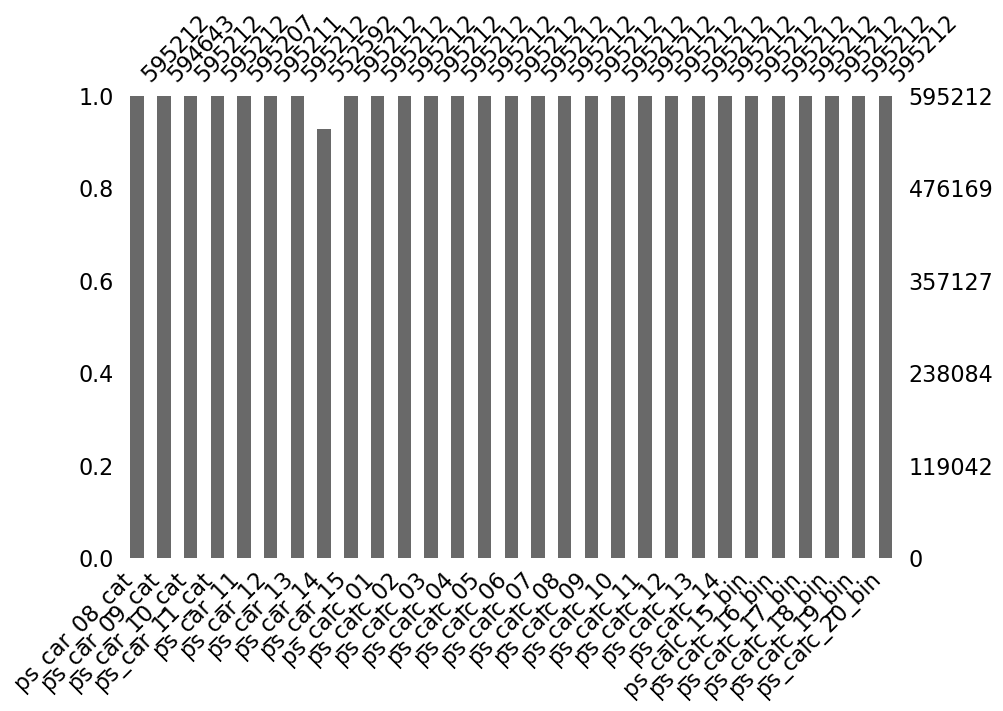

In [28]:
msno.bar(df = train_copy.iloc[:, 29:], figsize = (10, 6));

In [29]:
# "Feature Summary Table

def resumetable(df):
    print(f"Dataset shape: {df.shape}")
    summary = pd.DataFrame(df.dtypes, columns = ["data type"])
    summary["num_NaN"] = (df == -1).sum().values
    summary["num_Unique"] = df.nunique().values
    summary["Data Type"] = None
    for col in df.columns:
        if "bin" in col or col == "target":
            summary.loc[col, "Data Type"] = "Binary"
        elif "cat" in col:
            summary.loc[col, "Data Type"] = "Nominal"
        elif df[col].dtype == float:
            summary.loc[col, "Data Type"] = "Continuous"
        elif df[col].dtype == int:
            summary.loc[col, "Data Type"] = "Ordinal"

    return summary

In [30]:
summary = resumetable(train)
summary

Dataset shape: (595212, 58)


,data type,num_NaN,num_Unique,Data Type
target,int64,0,2,Binary
ps_ind_01,int64,0,8,Ordinal
ps_ind_02_cat,int64,216,5,Nominal
ps_ind_03,int64,0,12,Ordinal
ps_ind_04_cat,int64,83,3,Nominal
ps_ind_05_cat,int64,5809,8,Nominal
ps_ind_06_bin,int64,0,2,Binary
ps_ind_07_bin,int64,0,2,Binary
ps_ind_08_bin,int64,0,2,Binary
ps_ind_09_bin,int64,0,2,Binary


### 1.1 Visualization

In [31]:
def write_percent(ax, total_size):
    """Iterates over shape objects and 
    displays the target value ratio at the top of each bar"""
    for patch in ax.patches:
        height = patch.get_height()
        width = patch.get_width()
        left_coord = patch.get_x()
        percent = height/total_size * 100

        ax.text(x = left_coord + width/2.0,
                y = height + total_size * 0.001,
                s = f"{percent: 1.1f}%",
                ha = "center")

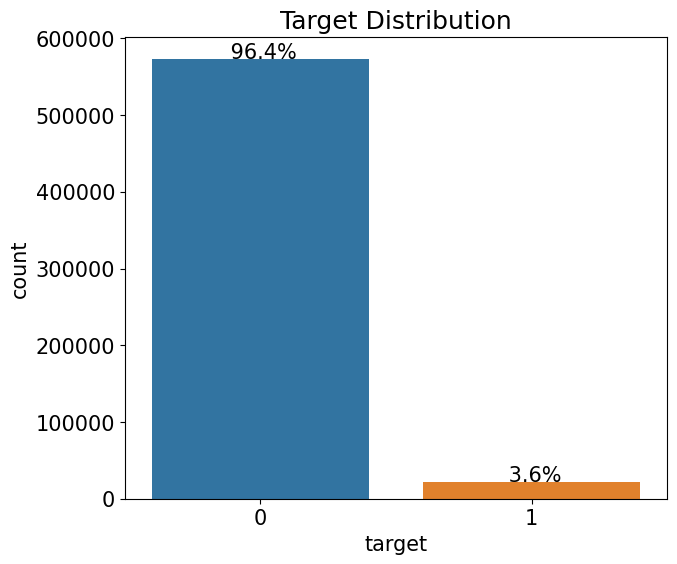

In [13]:
mpl.rc("font", size = 15)
plt.figure(figsize = (7, 6))

ax = sns.countplot(x = "target", data = train)
write_percent(ax, len(train))
ax.set_title("Target Distribution");

- The target value is imbalanced, making it crucial to accurately predict the minority target value, 1.
- Therefore, the proportion of target value 1 for each unique value of the features is checked to determine whether the feature is necessary for modeling.

In [32]:
# Binary features

def plot_target_ratio_by_features(df, features, num_rows, num_cols, size = (12, 18)):
    mpl.rc("font", size = 9)
    plt.figure(figsize = size)
    grid = gridspec.GridSpec(num_rows, num_cols)
    plt.subplots_adjust(wspace = 0.3, hspace = 0.3)

    for idx, feature in enumerate(features):
        ax = plt.subplot(grid[idx])
        sns.barplot(x = feature, y = "target", data = df, palette = "Set2", ax = ax)

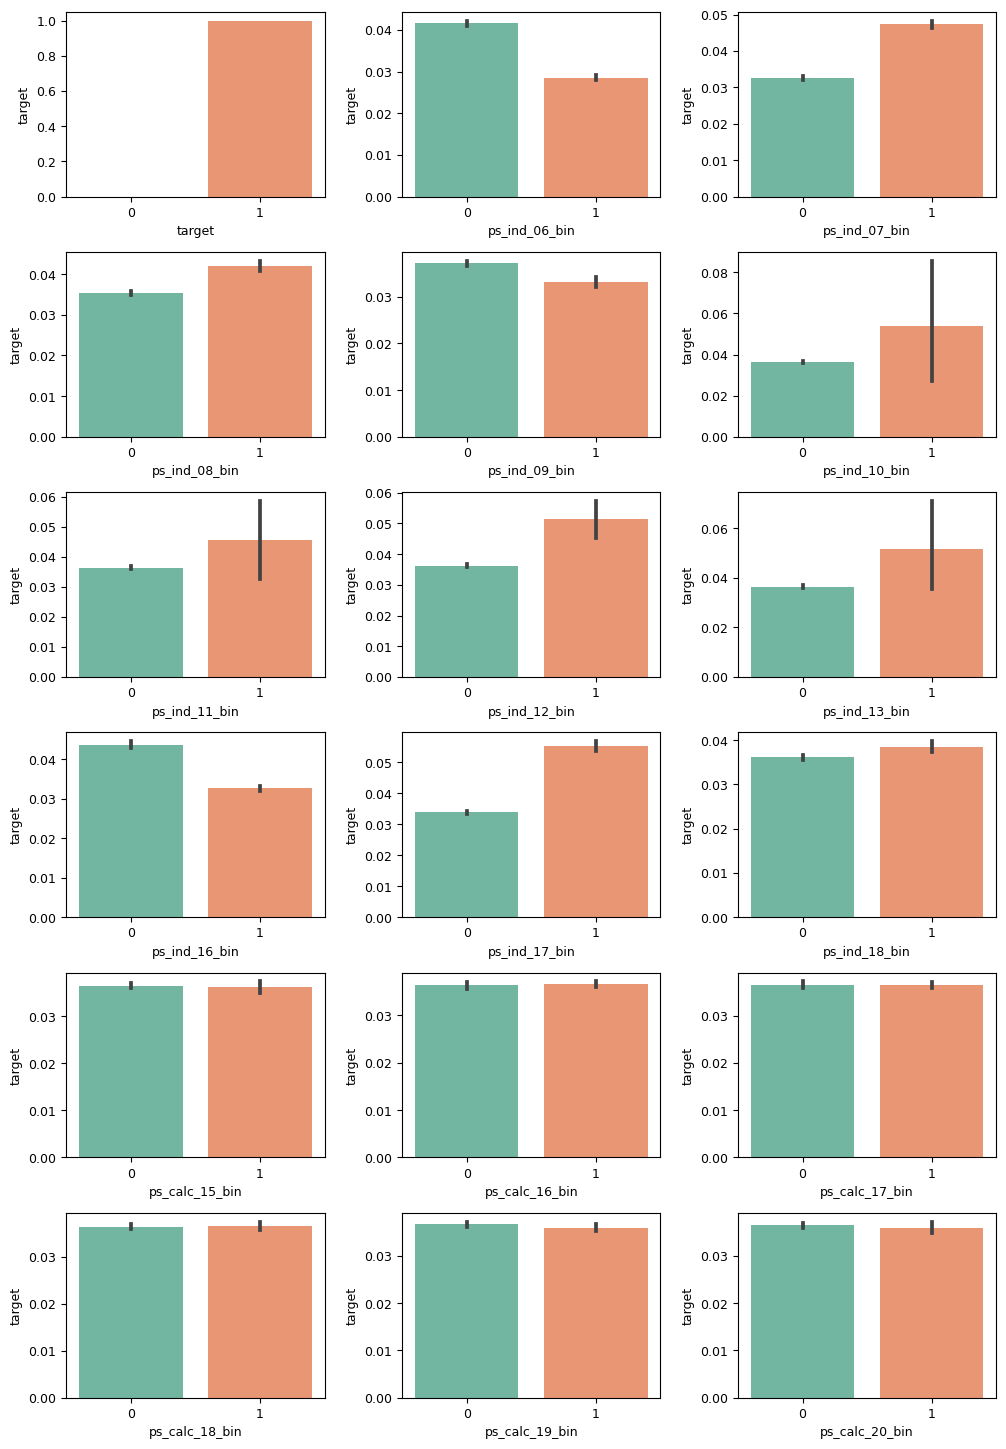

In [42]:
bin_features = summary[summary["Data Type"] == "Binary"].index
plot_target_ratio_by_features(train, bin_features, 6, 3)

- For the `ps_ind_06_bin` feature, the graph shows that when the value is 0, the proportion of target value 1 is 4%, while when the value is 1, the proportion is approximately 3%. This indicates that the target value proportions differ by unique values, meaning this feature has predictive power for estimating the target value. Additionally, the narrow confidence intervals suggest that this feature is statistically reliable and beneficial for modeling.
- On the other hand, `ps_ind_10_bin` to `ps_ind_13_bin` have wide confidence intervals, making them statistically less reliable.
- Similarly, `ps_calc_15_bin` to `ps_calc_20_bin` do not show differences in the target value proportions across unique values, indicating low predictive power for the target value.

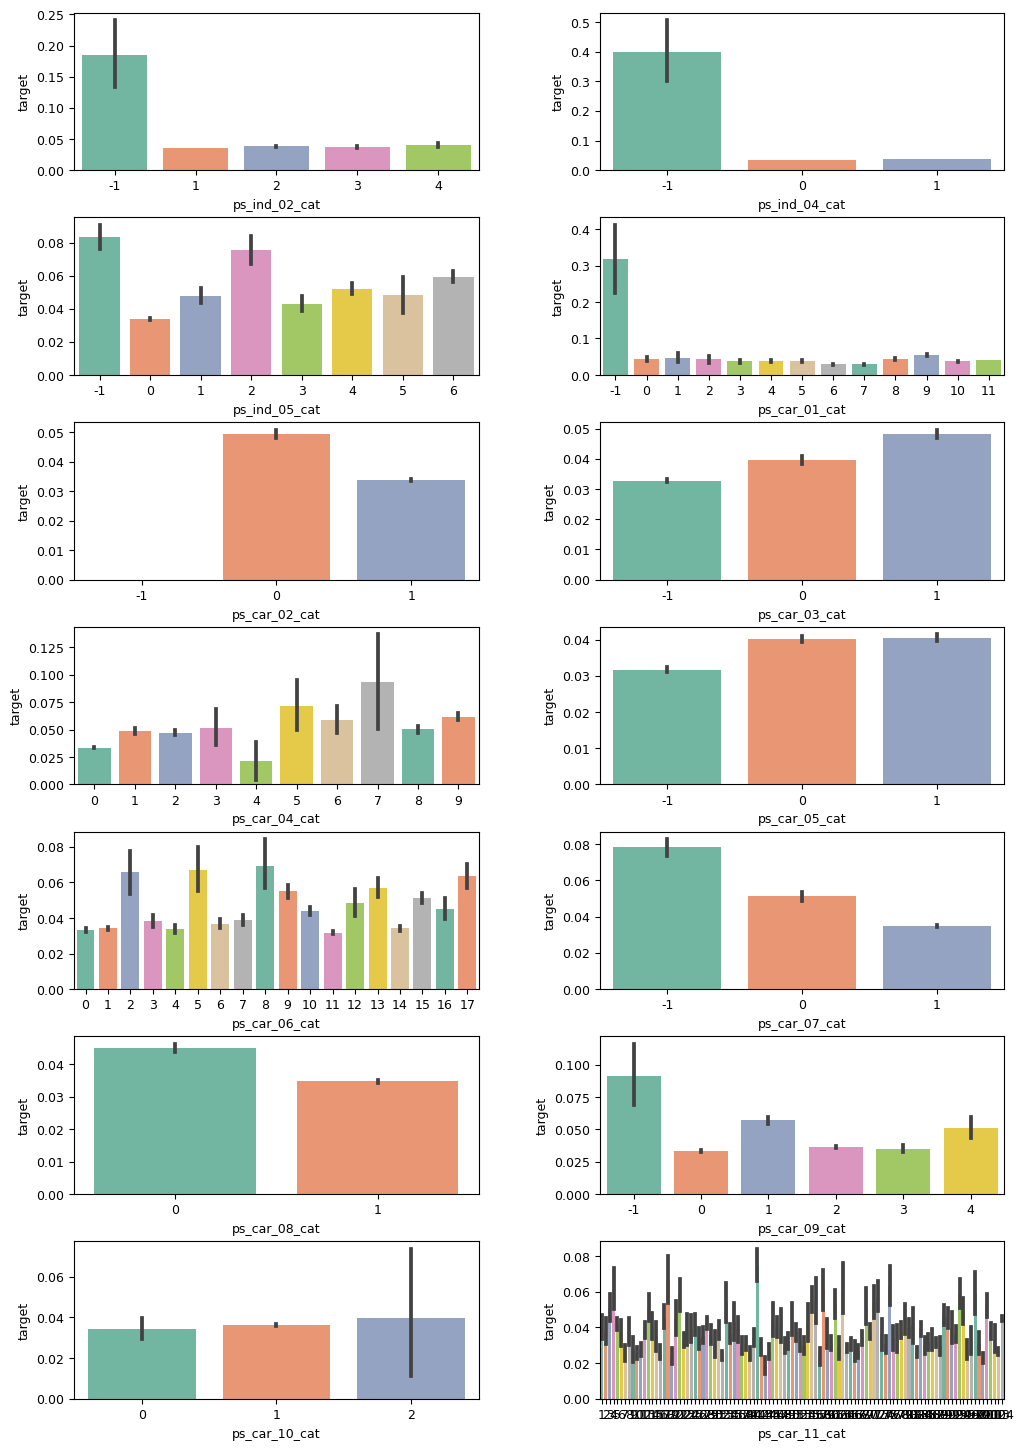

In [15]:
# nominal features

nom_features = summary[summary["Data Type"] == "Nominal"].index
plot_target_ratio_by_features(train, nom_features, 7, 2)

- Many features include the value -1, which represents missing data.
- For the `ps_ind_02_cat` feature, the proportion of target value 1 for the missing value (-1) is larger than for other unique values. Even considering the wide confidence interval, the proportion is noticeably higher. Since the missing value itself appears to have predictive power for the target value, it will be kept as is for modeling.
- All nominal features will be used because the differences in the proportion of target value 1 among their unique values are clear.

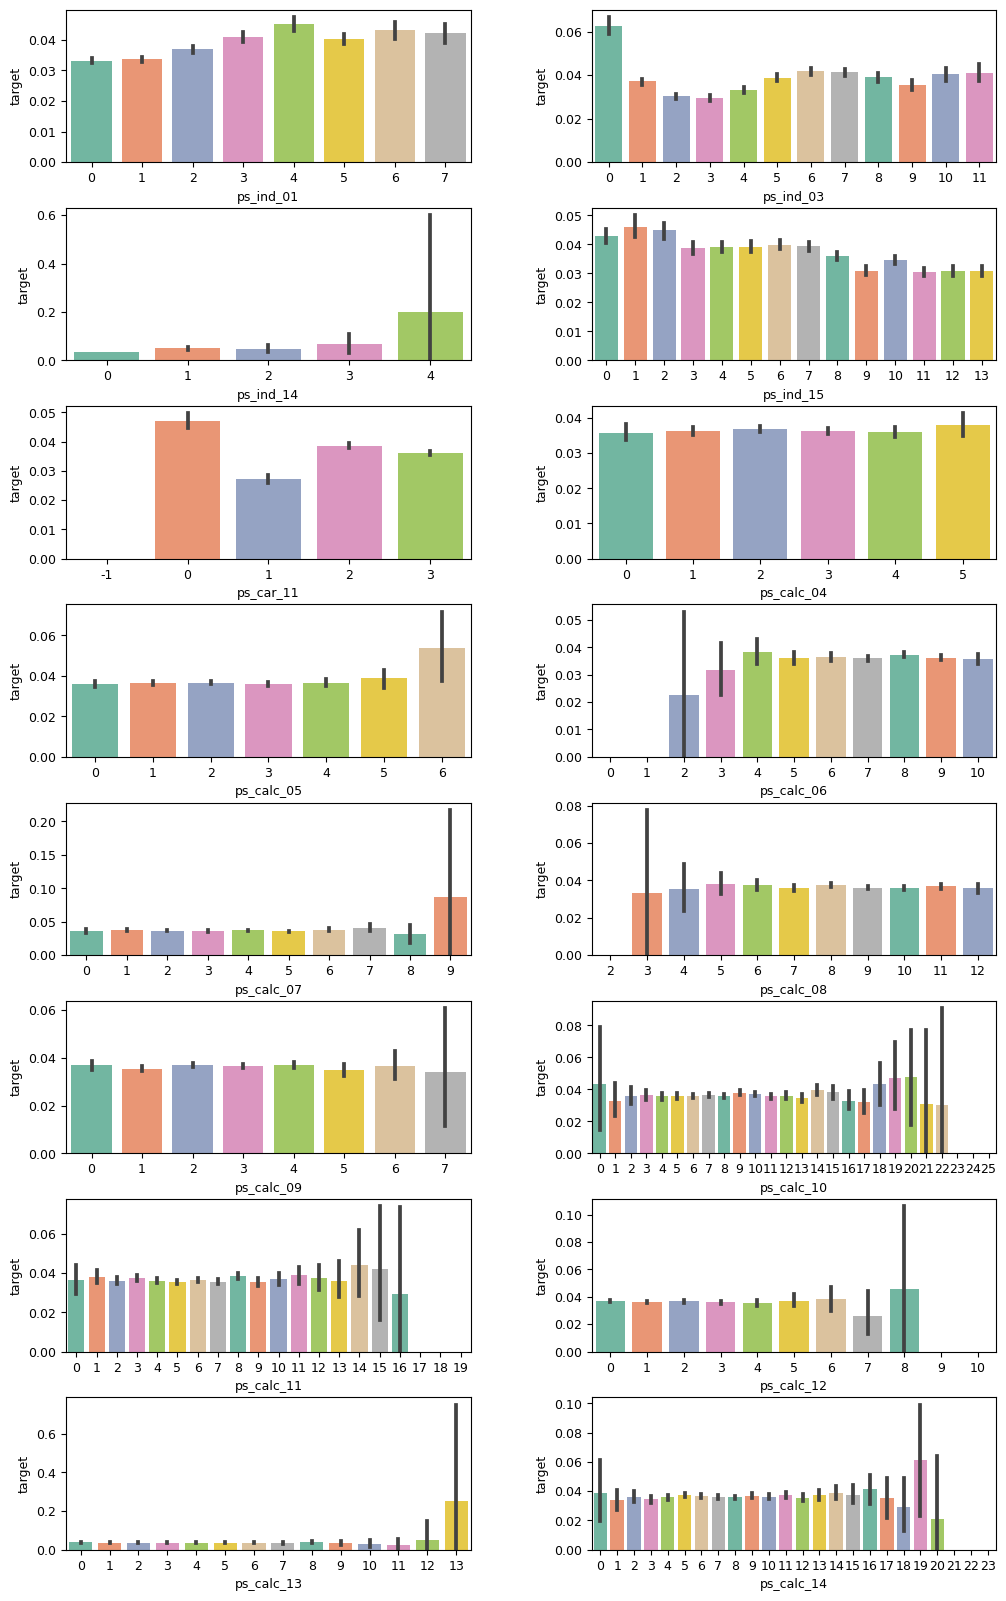

In [33]:
# Ordinal Features

ord_features = summary[summary["Data Type"] == "Ordinal"].index
plot_target_ratio_by_features(train, ord_features, 8, 2, (12, 20))

- The `ps_ind_14` feature shows little difference in the proportion of target value 1 across its unique values, and the confidence interval for the unique value 4 is particularly wide. Due to its significant lack of statistical reliability, this feature will be removed.
- For features `ps_calc_04` to `ps_calc_14`, the proportion of target value 1 is nearly identical across their unique values. While there are some unique values with different proportions, their wide confidence intervals make them statistically unreliable. Therefore, all these features will also be removed.

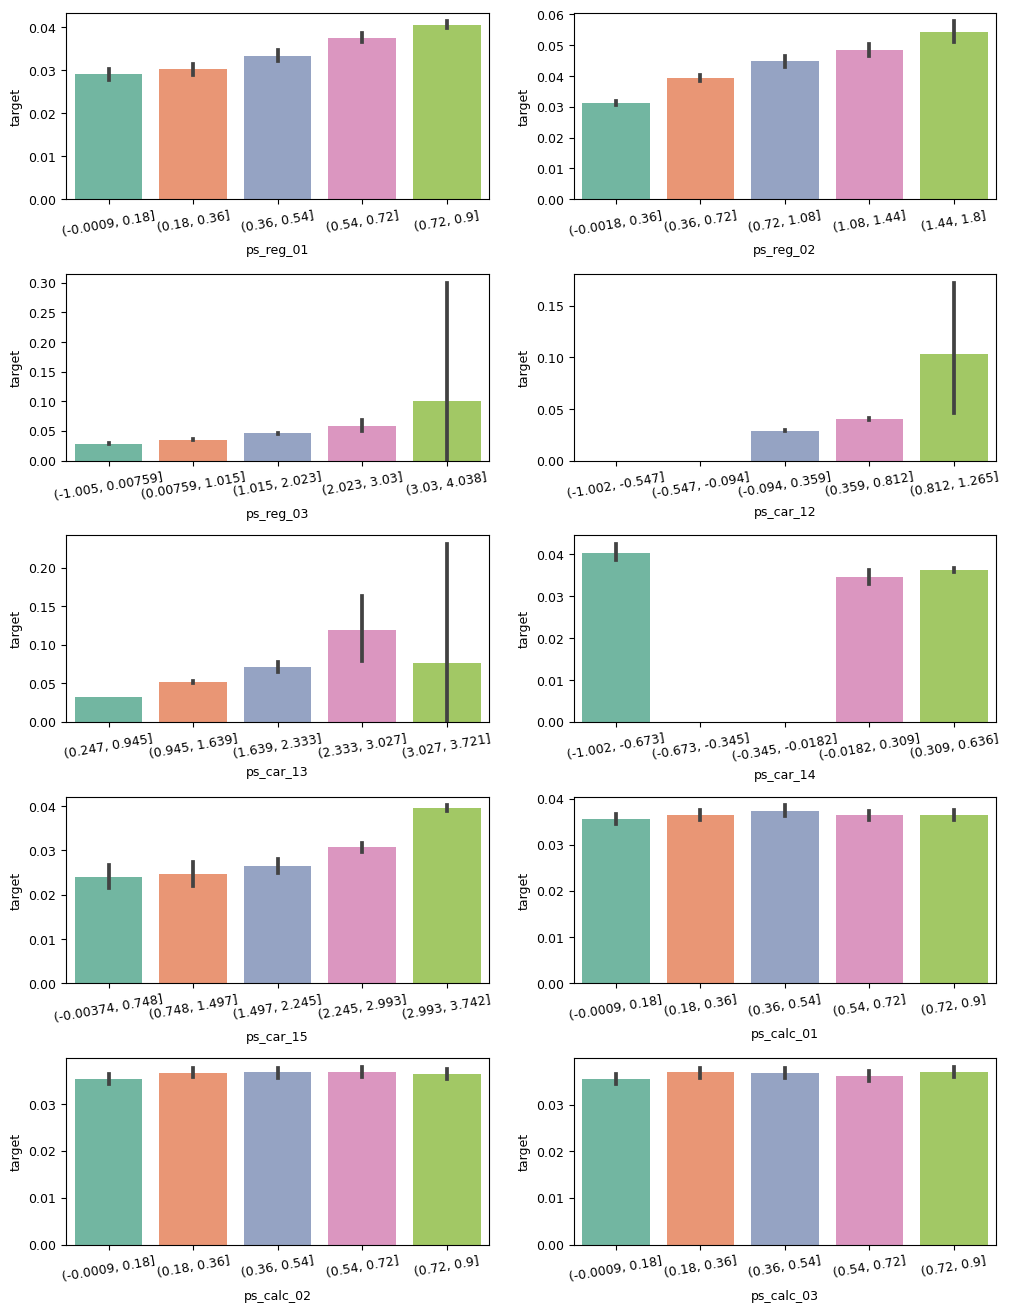

In [39]:
# Continuous features 

cont_features = summary[summary["Data Type"] == "Continuous"].index

plt.figure(figsize = (12, 16))
grid = gridspec.GridSpec(5, 2)
plt.subplots_adjust(wspace = 0.2, hspace = 0.4)

for idx, cont_feature in enumerate(cont_features):
    train[cont_feature] = pd.cut(train[cont_feature], 5)
    ax = plt.subplot(grid[idx])
    sns.barplot(x = cont_feature, y = "target", data = train, palette ="Set2", ax = ax)
    ax.tick_params(axis = "x", labelrotation =10)

- `ps_calc_01` to `ps_calc_03` have to be eliminated becuase these features show no difference in the proportion of target value 1.

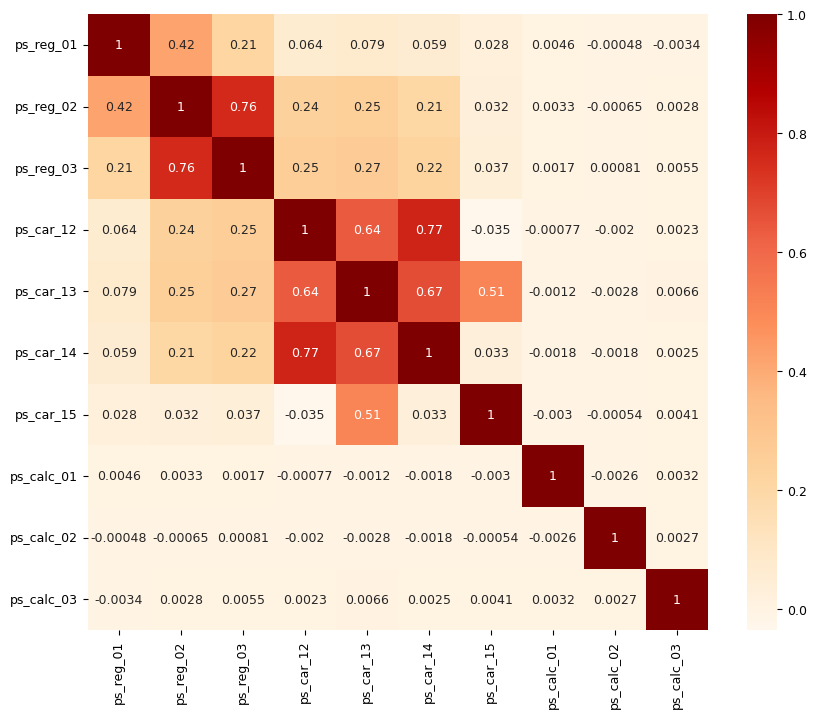

In [40]:
# correlation 

train_copy = train_copy.dropna()

plt.figure(figsize = (10, 8))
cont_corr = train_copy[cont_features].corr()
sns.heatmap(cont_corr, annot = True, cmap = "OrRd");

- I will drop the most highest correlation feature `ps_car_14` for better modeling

# 2. Baseline Model

### 2.1 Feature engineering

In [3]:
# data merge

all_data = pd.concat([train, test], ignore_index = True)
all_data = all_data.drop("target", axis = 1)

all_features = all_data.columns
all_features

Index(['ps_ind_01', 'ps_ind_02_cat', 'ps_ind_03', 'ps_ind_04_cat',
       'ps_ind_05_cat', 'ps_ind_06_bin', 'ps_ind_07_bin', 'ps_ind_08_bin',
       'ps_ind_09_bin', 'ps_ind_10_bin', 'ps_ind_11_bin', 'ps_ind_12_bin',
       'ps_ind_13_bin', 'ps_ind_14', 'ps_ind_15', 'ps_ind_16_bin',
       'ps_ind_17_bin', 'ps_ind_18_bin', 'ps_reg_01', 'ps_reg_02', 'ps_reg_03',
       'ps_car_01_cat', 'ps_car_02_cat', 'ps_car_03_cat', 'ps_car_04_cat',
       'ps_car_05_cat', 'ps_car_06_cat', 'ps_car_07_cat', 'ps_car_08_cat',
       'ps_car_09_cat', 'ps_car_10_cat', 'ps_car_11_cat', 'ps_car_11',
       'ps_car_12', 'ps_car_13', 'ps_car_14', 'ps_car_15', 'ps_calc_01',
       'ps_calc_02', 'ps_calc_03', 'ps_calc_04', 'ps_calc_05', 'ps_calc_06',
       'ps_calc_07', 'ps_calc_08', 'ps_calc_09', 'ps_calc_10', 'ps_calc_11',
       'ps_calc_12', 'ps_calc_13', 'ps_calc_14', 'ps_calc_15_bin',
       'ps_calc_16_bin', 'ps_calc_17_bin', 'ps_calc_18_bin', 'ps_calc_19_bin',
       'ps_calc_20_bin'],
      dtype='obj

In [4]:
# Nominal feature one-hot encoding

cat_features = [feature for feature in all_features if "cat" in feature]
onehot_encoder = OneHotEncoder()

encoded_cat_matrix = onehot_encoder.fit_transform(all_data[cat_features])

In [5]:
# Generate Derived Feature

all_data["num_missing"] = (all_data == -1).sum(axis = 1)
remaining_features = [feature for feature in all_features 
                      if ("cat" not in feature and "calc" not in feature)]

remaining_features.append("num_missing")

In [6]:
# feature that classficiation is "ind"

ind_features = [feature for feature in all_features if "ind" in feature]

is_first_feature = True

for ind_feature in ind_features:
    if is_first_feature:
        all_data["mix_ind"] = all_data[ind_feature].astype(str) + "_"
        is_first_feature = False
    else:
        all_data["mix_ind"] += all_data[ind_feature].astype(str) + "_"

In [7]:
# Add the count of unique values for Nominal Features as new feature

cat_count_features = []
for feature in cat_features + ["mix_ind"]:
    val_counts_dict = all_data[feature].value_counts().to_dict()
    all_data[f"{feature}_count"] = all_data[feature].apply(lambda x: val_counts_dict[x])
    cat_count_features.append(f"{feature}_count")

In [8]:
# Remove unnecessary Features

drop_features = ["ps_ind_14", "ps_ind_10_bin", "ps_ind_11_bin", "ps_ind_12_bin", "ps_ind_13_bin", "ps_car_14"]

all_data_remaining = all_data[remaining_features + cat_count_features].drop(drop_features, axis = 1)

all_data_sprs = sparse.hstack([sparse.csr_matrix(all_data_remaining), encoded_cat_matrix], format = "csr")
all_data_sprs

<1488028x217 sparse matrix of type '<class 'numpy.float64'>'
	with 61125924 stored elements in Compressed Sparse Row format>

In [9]:
# split the dataset

num_train = len(train)

X = all_data_sprs[: num_train]
X_test = all_data_sprs[num_train: ]

y = train["target"].values

### 2.2 Evaluation metrics

- The evaluation metric for this competition is the Normalized Gini Coefficient, which is not provided as a built-in function in Python or Scikit-learn. Therefore, a custom user-defined function must be implemented.
- The Gini Coefficient can be calculated as 2 × ROC AUC −1.
- The Normalized Gini Coefficient is defined as the Gini Coefficient for the predicted values divided by the Gini Coefficient for perfect predictions.
- The "Gini Coefficient for predicted values" refers to the Gini Coefficient calculated using the predicted values and actual values.
- The "Gini Coefficient for perfect predictions" refers to the Gini Coefficient calculated using the actual values against themselves.

In [10]:
def eval_gini(y_true, y_pred):
    assert y_true.shape == y_pred.shape

    n_samples = y_true.shape[0]
    L_mid = np.linspace(1 / n_samples, 1, n_samples) # diagonal line value

    # Gini Coefficient for predicted values
    pred_order = y_true[y_pred.argsort()]
    L_pred = np.cumsum(pred_order) / np.sum(pred_order) # Lorenz curve
    G_pred = np.sum(L_mid - L_pred) 

    # Gini Coefficient for perfect predictions
    true_order = y_true[y_true.argsort()]
    L_true = np.cumsum(true_order) / np.sum(true_order) 
    G_true = np.sum(L_mid - L_true) 

    return G_pred / G_true

In [11]:
def gini(preds, dtrain):
    labels = dtrain.get_label()
    return "gini", eval_gini(labels, preds)

### 2.3 hypterparameter optimization

In [12]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size = 0.2, random_state = 0)

bayes_dtrain = xgb.DMatrix(X_train, y_train)
bayes_dvalid = xgb.DMatrix(X_valid, y_valid)

In [13]:
param_bounds = {"max_depth": (4, 8),
                 "subsample": (0.7, 0.9),
                "colsample_bytree": (0.7, 1.0),
                "min_child_weight": (5, 7),
                "gamma": (8, 11),
                "reg_alpha": (7, 9),
                "reg_lambda": (1.1, 1.5),
                "scale_pos_weight": (1.4, 1.6)}

fixed_params = {"objective": "binary:logistic",
                "learning_rate": 0.02,
                "random_state": 1991}

In [14]:
# (bayesian optimization) evaluation function

def eval_function(max_depth, subsample, colsample_bytree, min_child_weight, reg_alpha, gamma, reg_lambda, scale_pos_weight):
    params = {"max_depth": int(round(max_depth)),
             "subsample": subsample,
            "colsample_bytree": colsample_bytree,
            "min_child_weight": min_child_weight,
            "gamma": gamma,
            "reg_alpha": reg_alpha,
            "reg_lambda": reg_lambda,
            "scale_pos_weight": scale_pos_weight}

    params.update(fixed_params)
    print("hyperparameter:", params)
    xgb_model = xgb.train(params = params,
                          dtrain = bayes_dtrain,
                          num_boost_round = 2000,
                          evals = [(bayes_dvalid, "bayes_dvalid")],
                          maximize = True,
                          custom_metric = gini,
                         early_stopping_rounds = 200)

    best_iter = xgb_model.best_iteration
    preds = xgb_model.predict(bayes_dvalid, iteration_range = (0, best_iter))
    gini_score = eval_gini(y_valid, preds)
    print(f"gini coefficient: {gini_score}\n")

    return gini_score

In [15]:
optimizer = BayesianOptimization(f = eval_function,
                                 pbounds = param_bounds,
                                 random_state = 0)

In [16]:
optimizer.maximize(init_points = 3, n_iter = 6)

|   iter    |  target   | colsam... |   gamma   | max_depth | min_ch... | reg_alpha | reg_la... | scale_... | subsample |
-------------------------------------------------------------------------------------------------------------------------
hyperparameter: {'max_depth': 6, 'subsample': 0.878354600156416, 'colsample_bytree': 0.8646440511781974, 'min_child_weight': 6.0897663659937935, 'gamma': 10.14556809911726, 'reg_alpha': 7.84730959867781, 'reg_lambda': 1.3583576452266626, 'scale_pos_weight': 1.4875174422525386, 'objective': 'binary:logistic', 'learning_rate': 0.02, 'random_state': 1991}
[0]	bayes_dvalid-logloss:0.21799	bayes_dvalid-gini:0.20314
[1]	bayes_dvalid-logloss:0.21642	bayes_dvalid-gini:0.21338
[2]	bayes_dvalid-logloss:0.21488	bayes_dvalid-gini:0.21631
[3]	bayes_dvalid-logloss:0.21339	bayes_dvalid-gini:0.21982
[4]	bayes_dvalid-logloss:0.21194	bayes_dvalid-gini:0.22287
[5]	bayes_dvalid-logloss:0.21053	bayes_dvalid-gini:0.22547
[6]	bayes_dvalid-logloss:0.20916	bayes_dvalid-g

In [17]:
max_params = optimizer.max['params']
max_params

{'colsample_bytree': 0.8889849533401327,
 'gamma': 8.869737053393713,
 'max_depth': 6.816456938537565,
 'min_child_weight': 6.906734355827464,
 'reg_alpha': 7.583768658822853,
 'reg_lambda': 1.3993590337396538,
 'scale_pos_weight': 1.5044319898933365,
 'subsample': 0.7481834785113651}

In [18]:
max_params["max_depth"] = int(round(max_params["max_depth"]))
max_params.update(fixed_params)

In [21]:
max_params

{'colsample_bytree': 0.8889849533401327,
 'gamma': 8.869737053393713,
 'max_depth': 7,
 'min_child_weight': 6.906734355827464,
 'reg_alpha': 7.583768658822853,
 'reg_lambda': 1.3993590337396538,
 'scale_pos_weight': 1.5044319898933365,
 'subsample': 0.7481834785113651,
 'objective': 'binary:logistic',
 'learning_rate': 0.02,
 'random_state': 1991}

### 2.4 Model training + Evaluate performance

In [22]:
folds = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 1991)

oof_val_preds = np.zeros(X.shape[0])
oof_test_preds = np.zeros(X_test.shape[0])

for idx, (train_idx, valid_idx) in enumerate(folds.split(X, y)):
    print("#" * 40, f"fold {idx + 1} / fold {folds.n_splits}", "#" * 40)

    X_train, y_train = X[train_idx], y[train_idx]
    X_valid, y_valid = X[valid_idx], y[valid_idx]

    dtrain = xgb.DMatrix(X_train, y_train)
    dvalid = xgb.DMatrix(X_valid, y_valid)
    dtest = xgb.DMatrix(X_test)

    xgb_model = xgb.train(params = max_params,
                          dtrain = dtrain,
                          num_boost_round = 2000,
                          evals = [(dvalid, "valid")],
                          maximize = True,
                          custom_metric = gini,
                          early_stopping_rounds = 200)

    best_iter = xgb_model.best_iteration
    oof_test_preds += xgb_model.predict(dtest, iteration_range = (0, best_iter)) / folds.n_splits
    
    oof_val_preds[valid_idx] += xgb_model.predict(dvalid, iteration_range = (0, best_iter))

    gini_score = eval_gini(y_valid, oof_val_preds[valid_idx])
    print(f"fold {idx + 1} gini coefficient: {gini_score}\n")

######################################## fold 1 / fold 5 ########################################
[0]	valid-logloss:0.21862	valid-gini:0.21275
[1]	valid-logloss:0.21705	valid-gini:0.23194
[2]	valid-logloss:0.21552	valid-gini:0.24155
[3]	valid-logloss:0.21404	valid-gini:0.24435
[4]	valid-logloss:0.21259	valid-gini:0.24721
[5]	valid-logloss:0.21119	valid-gini:0.24864
[6]	valid-logloss:0.20981	valid-gini:0.25061
[7]	valid-logloss:0.20848	valid-gini:0.25018
[8]	valid-logloss:0.20718	valid-gini:0.25050
[9]	valid-logloss:0.20591	valid-gini:0.25112
[10]	valid-logloss:0.20467	valid-gini:0.25008
[11]	valid-logloss:0.20346	valid-gini:0.24979
[12]	valid-logloss:0.20229	valid-gini:0.24912
[13]	valid-logloss:0.20113	valid-gini:0.24999
[14]	valid-logloss:0.20001	valid-gini:0.25059
[15]	valid-logloss:0.19892	valid-gini:0.24999
[16]	valid-logloss:0.19786	valid-gini:0.24986
[17]	valid-logloss:0.19682	valid-gini:0.25044
[18]	valid-logloss:0.19581	valid-gini:0.25037
[19]	valid-logloss:0.19482	valid-gini:

In [23]:
print("OOF valid data gini coefficient: ", eval_gini(y, oof_val_preds))

OOF valid data gini coefficient:  0.2843570180160076


# 3. Submission

In [24]:
submission["target"] = oof_test_preds
submission.to_csv("submission.csv")